# YOLO Training Notebook
Author: Cait Newport
Date: 2025-01-21

In this notebook we will train a YOLOv8 model to detect a single species of fish
YOLO (You Only Look Once) detectors are particularly well-suited to the task of detecting a single or a small number of animal species for several reasons:

1. **Single Species Detection**: YOLO performs exceptionally well with small numbers of classes, making it ideal for our single-species detection task. The model can focus its learning capacity on recognizing the specific features of our target species.

2. **Speed & Efficiency**: As a single-stage detector, YOLO processes images in one pass, making it significantly faster than two-stage detectors like R-CNN. This efficiency is valuable for processing large wildlife datasets.

3. **End-to-End Training**: YOLO trains on full images directly, allowing it to learn both the specific features of our target species and the contextual information about its habitat and typical surroundings.

4. **Good Balance of Speed vs Accuracy**: While some two-stage detectors might achieve marginally higher accuracy, YOLO provides excellent detection performance while maintaining fast inference times, making it practical for both research and field applications.

This tutorial assumes you have a dataset in YOLO format.

## 1. Environment Setup
This has been tested on a Mac with M3 chip.

In [89]:
# RUN COMMANDS IN THIS CELL FROM THE TERMINAL or with ! in front of the command in a cell

# You will get error messages if you try to install torch with newer python versions. Stick with Python 3.1
!brew install python@3.11

# Create and activate a Python virtual environment
!python3.11 -m venv yolo_training_enviro # Only need to do this once
!source yolo_training_enviro/bin/activate

# Install ipykernel if not already installed
!pip install ipykernel
# Register the kernel with Jupyter
!python -m ipykernel install --user --name=yolo_training_enviro --display-name="YOLO Training (Python 3.11)"
# In later stages you may get errors about 'import'. You may need to change your kernel to the one you just created.
# You can do this by clicking on the kernel in the top right of the notebook and selecting the kernel you want.
# Choose "YOLO Training (Python 3.11)" which you just made.

==> Auto-updating Homebrew...
Adjust how often this is run with HOMEBREW_AUTO_UPDATE_SECS or disable with
HOMEBREW_NO_AUTO_UPDATE. Hide these hints with HOMEBREW_NO_ENV_HINTS (see `man brew`).
==> Auto-updated Homebrew!
Updated 2 taps (homebrew/core and homebrew/cask).
==> New Formulae
acme.sh      chiko        precious     sdl3         umka-lang    xprop
babelfish    ludusavi     redocly-cli  ubi          xlsclients   xwininfo
==> New Casks
dana-dex                                 font-monomakh
dockfix                                  imaging-edge-webcam
flashspace                               jottacloud
flowvision                               linearmouse@beta
font-bitcount                            muteme
font-bitcount-prop-single-ink            startupfolder
font-bitcount-single-ink                 valhalla-freq-echo
font-maple-mono-cn                       valhalla-space-modulator
font-maple-mono-nf-cn                    valhalla-supermassive

You have 26 outdated formulae and 1

In [ ]:

# Verify the kernel is correct by running this cell:
import sys
print(sys.executable)  # This will show which Python interpreter you're using
# It should now show a path that includes your virtual environment (yolo_training_enviro)

In [ ]:
# Install Torch. 
pip install torch torchvision torchaudio

In [3]:
# Torch can be optimized for a MAC M3 chip. To check if it is, run this cell:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"MPS (Metal) available: {torch.backends.mps.is_available()}")
print(f"Current device: {torch.device('mps' if torch.backends.mps.is_available() else 'cpu')}")

# You shuld see that MPS is available and the current device is mps.
# If not, you may need to reinstall torch.


PyTorch version: 2.5.1
MPS (Metal) available: True
Current device: mps


## 2. Data Preparation
You will need to have a dataset in YOLO format.
You should start with the raw_data folder and we will create the dataset folder.

project_root/
    ├── raw_data/              
    │   ├── images/
    │   │   ├── image1.jpg
    │   │   ├── image2.jpg
    │   │   └── image3.jpg
    │   └── labels/
    │       ├── image1.txt    # Contains: "0 0.5 0.5 0.2 0.2"
    │       ├── image2.txt    # Contains: "1 0.3 0.7 0.4 0.3"
    │       └── image3.txt    # Contains: "2 0.6 0.4 0.3 0.2"
    │
    ├── datasets/              
    │   └── dataset_v1/        
    │       ├── images/
    │       │   ├── train/
    │       │   │   ├── image1.jpg
    │       │   │   └── image2.jpg
    │       │   └── val/
    │       │       └── image3.jpg
    │       └── labels/
    │           ├── train/
    │           │   ├── image1.txt
    │           │   └── image2.txt
    │           └── val/
    │               └── image3.txt
    │
    └── data.yaml             # Contains:
                             # train: datasets/dataset_v1/images/train
                             # val: datasets/dataset_v1/images/val
                             # nc: 3
                             # names: ['dog', 'cat', 'bird']

  A text file would have the classes listed in order. For example:
  triggerfish
  shark
  octopus

A data.yaml file would have the classes listed in order. For example:

names:
  0: triggerfish
  1: shark
  2: octopus    


### 2.1 Viewing the dataset

In [1]:
# To see some of your images with annotations:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

In [17]:
# Update these paths to match your directory structure
IMAGE_DIR = "./triggerfish_detection/raw_data/images"
LABEL_DIR = "./triggerfish_detection/raw_data/labels"
class_names = ["triggerfish"]  # Replace with your classes

# Choose a specific image to visualize
image_name = "image_0007.jpg"  # Replace with your image name
label_name = image_name.replace('.jpg', '.txt')

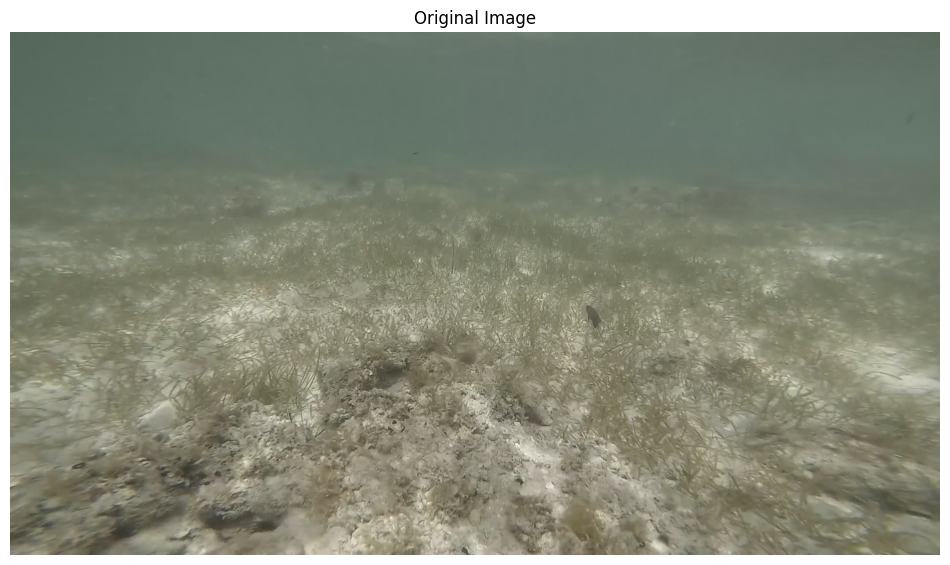

In [18]:
# Read image
image_path = os.path.join(IMAGE_DIR, image_name)
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show original image
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis('off')
plt.title('Original Image')
plt.show()

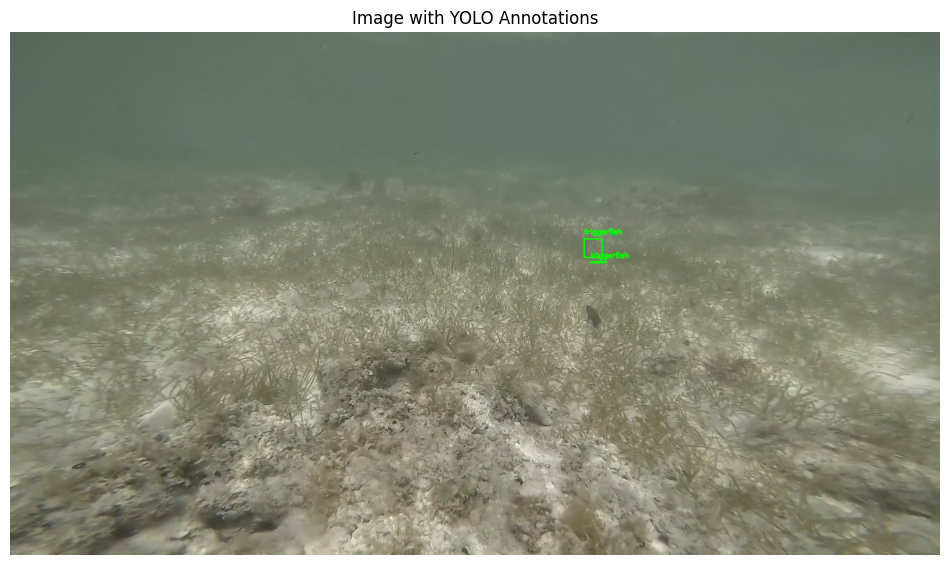

In [19]:
# Read annotations
label_path = os.path.join(LABEL_DIR, label_name)
boxes = []

with open(label_path, 'r') as f:
    for line in f.readlines():
        class_id, x_center, y_center, width, height = map(float, line.strip().split())
        boxes.append([int(class_id), x_center, y_center, width, height])

# Convert and draw boxes
img_height, img_width = img.shape[:2]
img_with_boxes = img.copy()

for box in boxes:
    class_id, x_center, y_center, width, height = box
    
    # Convert normalized coordinates to pixel coordinates
    x = int((x_center - width/2) * img_width)
    y = int((y_center - height/2) * img_height)
    w = int(width * img_width)
    h = int(height * img_height)
    
    # Draw rectangle
    cv2.rectangle(img_with_boxes, (x, y), (x + w, y + h), (0, 255, 0), 2)
    
    # Add label
    label = class_names[int(class_id)] if class_names else str(int(class_id))
    cv2.putText(img_with_boxes, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# Display image with boxes
plt.figure(figsize=(12, 8))
plt.imshow(img_with_boxes)
plt.axis('off')
plt.title('Image with YOLO Annotations')
plt.show()

To View multiple samples:

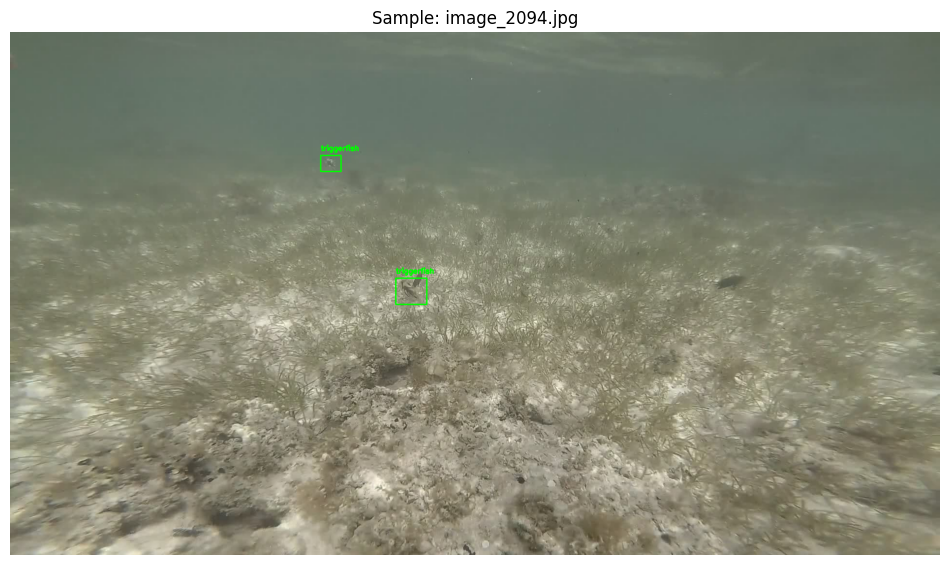

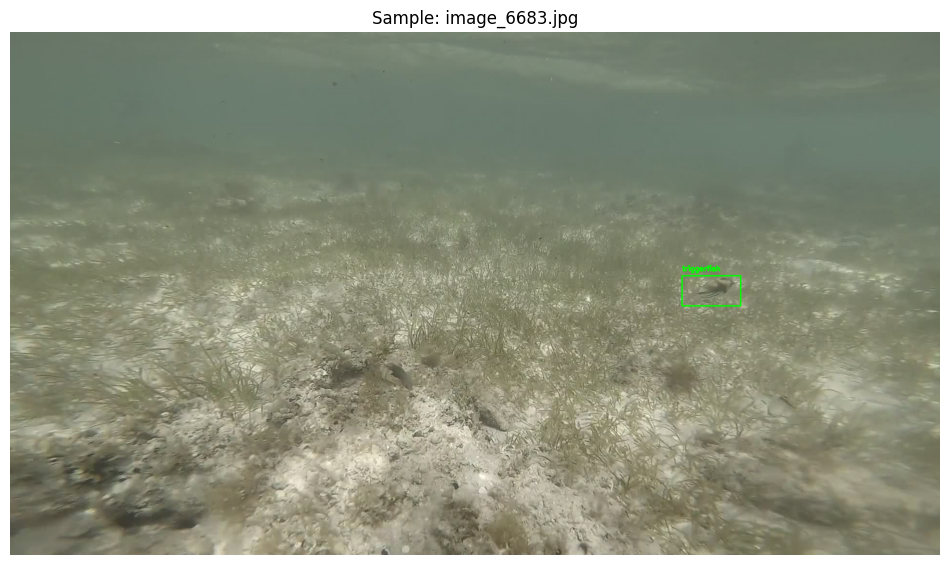

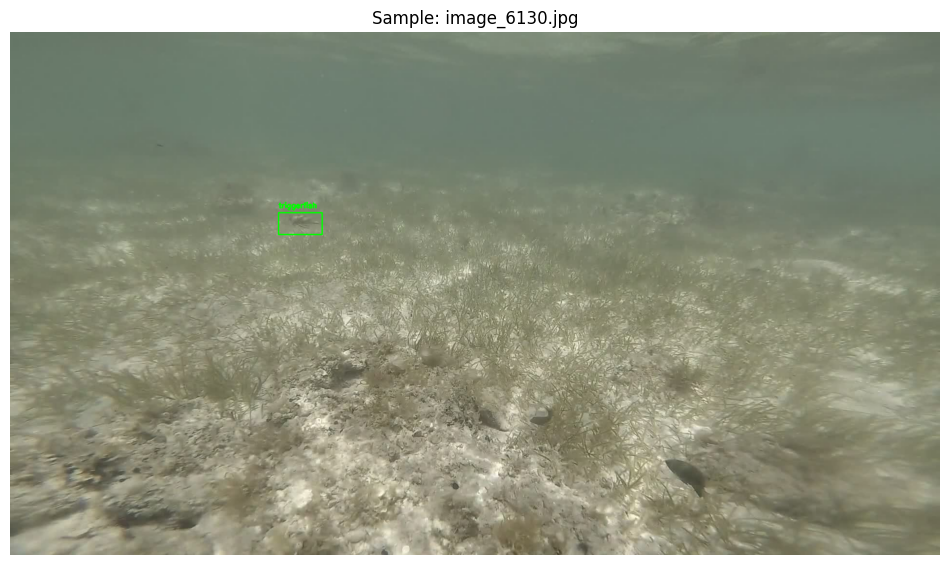

In [16]:
# Get list of image files
image_files = [f for f in os.listdir(IMAGE_DIR) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Select random samples
num_samples = 3  # Change this to view more or fewer samples
samples = np.random.choice(image_files, num_samples)

# Process each sample
for image_name in samples:
    label_name = image_name.replace('.jpg', '.txt')
    
    # Read image
    image_path = os.path.join(IMAGE_DIR, image_name)
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Read annotations
    label_path = os.path.join(LABEL_DIR, label_name)
    boxes = []
    
    with open(label_path, 'r') as f:
        for line in f.readlines():
            class_id, x_center, y_center, width, height = map(float, line.strip().split())
            boxes.append([int(class_id), x_center, y_center, width, height])
    
    # Draw boxes
    img_height, img_width = img.shape[:2]
    
    for box in boxes:
        class_id, x_center, y_center, width, height = box
        x = int((x_center - width/2) * img_width)
        y = int((y_center - height/2) * img_height)
        w = int(width * img_width)
        h = int(height * img_height)
        
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
        label = class_names[int(class_id)] if class_names else str(int(class_id))
        cv2.putText(img, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    # Display
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Sample: {image_name}')
    plt.show()

## 3. Validating the dataset

It is important to get your dataset right before training. <b>Data leakage</b> is when information from your test set accidentally gets into your training set and influences model training. It can create unrealistic performance metrics. Common cases include preprocessing data before splitting, using test set statistics, or having duplicate/related samples across splits.

To prevent it: split data first, preprocess using only training data statistics, and maintain strict separation of test data throughout the pipeline.

Other issues that can occur are having incorrect labels, or having duplicate/related samples across splits. Here we will add some checks to make sure the dataset is valid.

### 3.1 Checking for duplicate images


In [ ]:
import hashlib
from pathlib import Path

# Update this path to match your image directory
IMAGE_DIR = "./triggerfish_detection/raw_data/images"

def get_file_hash(filepath):
    """Calculate MD5 hash of a file"""
    md5_hash = hashlib.md5()
    with open(filepath, "rb") as f:
        # Read the file in chunks to handle large files
        for chunk in iter(lambda: f.read(4096), b""):
            md5_hash.update(chunk)
    return md5_hash.hexdigest()

# Get all image files
image_files = list(Path(IMAGE_DIR).glob('*.jpg')) + \
              list(Path(IMAGE_DIR).glob('*.jpeg')) + \
              list(Path(IMAGE_DIR).glob('*.png'))

print(f"Total images found: {len(image_files)}")

# Dictionary to store file hashes
file_hashes = {}
duplicates = []

# Check for duplicates
for img_path in image_files:
    file_hash = get_file_hash(img_path)
    if file_hash in file_hashes:
        duplicates.append((img_path, file_hashes[file_hash]))
    else:
        file_hashes[file_hash] = img_path

# Print results
if duplicates:
    print("\nFound duplicate images:")
    for dup, orig in duplicates:
        print(f"Duplicate: {dup.name} is identical to {orig.name}")
else:
    print("\nNo duplicate images found.")


In [ ]:
# Display duplicate images

import matplotlib.pyplot as plt
import cv2

def show_duplicate_pair(img1_path, img2_path):
    """Display a pair of duplicate images side by side"""
    # Read images
    img1 = cv2.imread(str(img1_path))
    img2 = cv2.imread(str(img2_path))
    
    # Convert from BGR to RGB
    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
    
    # Create figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Display images
    ax1.imshow(img1)
    ax1.set_title(f'Original: {img1_path.name}')
    ax1.axis('off')
    
    ax2.imshow(img2)
    ax2.set_title(f'Duplicate: {img2_path.name}')
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()

# Show all duplicate pairs
if duplicates:
    print(f"Found {len(duplicates)} duplicate pairs")
    for dup, orig in duplicates:
        show_duplicate_pair(orig, dup)
else:
    print("No duplicates to display")

In my dataset I found 77 duplicate images. After inspecting them, I found that they were all the same image. 

The next step is to remove them from the dataset. I will keep the first instance and remove the duplicates.

Rather than deleting duplicates from the raw_data folder, I will get a list of the files to keep. 

In [20]:
# Get list of files to keep (excluding duplicates)
import os

image_dir = "./triggerfish_detection/raw_data/images"

duplicate_filenames = set(dup.name for dup, _ in duplicates)
image_files = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
files_to_keep = [f for f in image_files if f not in duplicate_filenames]

print(f"Total original images: {len(image_files)}")
print(f"Duplicate images: {len(duplicate_filenames)}")
print(f"Images to keep: {len(files_to_keep)}")


Total original images: 8787
Duplicate images: 77
Images to keep: 8710


### 3.2 Checking for missing labels

In this example, there are duplicate images. These are actual errors in the dataset and will be removed. 

Another check you can do is whether you are missing labels. While sometimes these can be due to errors in the dataset, they can also be cases of "negative" samples. These samples are not labeled, but they are still important for training for several reasons:

1. They help the model learn what is not an object. This is crucial for distinguishing between objects and background.
2. They can help with generalization. If a model only sees positive samples, it may not learn to distinguish between similar objects.
3. They can help with data augmentation. If a model only sees positive samples, it may not learn to distinguish between similar objects.

The proportion of negative samples depends on your use case. If false positives are costly, you may want to include more negative samples. A common starting point is 20% negative samples.

In [14]:
# Update these paths to match your directory structure
LABEL_DIR = "./triggerfish_detection/raw_data/labels"

def check_label_content(filepath):
    """Read label file and check if it's empty or contains only zeros"""
    try:
        with open(filepath, 'r') as f:
            content = f.read().strip()
            if not content:  # Empty file
                return "empty"
            
            # Check if all values are zero
            values = [float(val) for line in content.split('\n') 
                     for val in line.strip().split()[1:]]  # Skip class ID
            if all(v == 0.0 for v in values):
                return "zeros"
            
            return "valid"
    except Exception as e:
        return f"error: {str(e)}"

# Get all label files
label_files = list(Path(LABEL_DIR).glob('*.txt'))
print(f"Total label files found: {len(label_files)}")

# Check each label file
empty_labels = []
zero_labels = []
error_labels = []

for label_path in label_files:
    status = check_label_content(label_path)
    if status == "empty":
        empty_labels.append(label_path)
    elif status == "zeros":
        zero_labels.append(label_path)
    elif status.startswith("error"):
        error_labels.append((label_path, status))

# Print results
print("\nLabel File Analysis:")
print(f"Empty label files: {len(empty_labels)}")
print(f"Zero-value label files: {len(zero_labels)}")
print(f"Files with errors: {len(error_labels)}")
print(f"Negative label percentage: {len(empty_labels)/len(label_files)*100}%")

#if empty_labels:
#    print("\nEmpty label files:")
#    for path in empty_labels:
#        print(f"- {path.name}")

if zero_labels:
    print("\nZero-value label files:")
    for path in zero_labels:
        print(f"- {path.name}")

if error_labels:
    print("\nFiles with errors:")
    for path, error in error_labels:
        print(f"- {path.name}: {error}")

Total label files found: 8787

Label File Analysis:
Empty label files: 185
Zero-value label files: 0
Files with errors: 0
Negative label percentage: 2.1053829520883123%


### 3.3 Checking for duplicate labels

This is where the labels are the same but the image is different. 
This sort of error is not common, but could indicate that there are issues in the dataset and pairing of images and labels. 

In [ ]:
# This script ignores the duplicate images and empty labels and only checks for duplicate labels. 

# Update these paths to match your directory structure
LABEL_DIR = "./triggerfish_detection/raw_data/labels"

def read_label_file(filepath):
    """Read and return the contents of a label file"""
    with open(filepath, 'r') as f:
        content = f.read().strip()
        if not content:  # Skip empty files
            return None
        # Check if all values (except class ID) are zero
        values = [float(val) for line in content.split('\n') 
                 for val in line.strip().split()[1:]]
        if all(v == 0.0 for v in values):  # Skip zero-value files
            return None
        return content

# Get all label files
label_files = list(Path(LABEL_DIR).glob('*.txt'))
print(f"Total label files found: {len(label_files)}")

# Dictionary to store label contents and their files
label_contents = {}
duplicate_labels = []
empty_or_zero_labels = []

# Check for duplicates
for label_path in label_files:
    content = read_label_file(label_path)
    if content is None:
        empty_or_zero_labels.append(label_path)
        continue
    if content in label_contents:
        duplicate_labels.append((label_path, label_contents[content]))
    else:
        label_contents[content] = label_path

# Print summary at top
print(f"\nFound {len(duplicate_labels)} duplicate label files")
print(f"Found {len(duplicates)} duplicate image files")
print(f"Found {len(empty_or_zero_labels)} empty or zero-value label files (ignored)")

# Print detailed results
if duplicate_labels:
    print("\nFound duplicate labels:")
    for dup, orig in duplicate_labels:
        print(f"\nDuplicate: {dup.name} is identical to {orig.name}")
        print(f"Content: {read_label_file(dup)}")
else:
    print("\nNo duplicate labels found.")

# Check if label duplicates correspond to image duplicates
if duplicate_labels:
    print("\nChecking if label duplicates match image duplicates:")
    image_duplicate_pairs = set((str(dup.stem), str(orig.stem)) for dup, orig in duplicates)
    label_duplicate_pairs = set((str(dup.stem), str(orig.stem)) for dup, orig in duplicate_labels)
    
    matching_pairs = image_duplicate_pairs & label_duplicate_pairs
    
    if len(matching_pairs) == len(image_duplicate_pairs) == len(label_duplicate_pairs):
        print("\n✓ Perfect match: All duplicate images have matching duplicate labels!")
    else:
        print(f"\nNumber of matching duplicate pairs: {len(matching_pairs)}")
        print(f"Number of image duplicate pairs: {len(image_duplicate_pairs)}")
        print(f"Number of label duplicate pairs: {len(label_duplicate_pairs)}")
        print("\nWarning: Mismatch in duplicate pairs!")
        print("This might indicate data inconsistency.")

You can see that there are duplicate labels. Inspect these to check if they are actual errors.

In [16]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def show_image_with_labels(img_path, label_path, class_names=["triggerfish"]):
    """Display an image with its YOLO labels"""
    # Read image
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Read labels
    with open(label_path, 'r') as f:
        labels = [line.strip().split() for line in f.readlines()]
    
    # Draw boxes
    img_height, img_width = img.shape[:2]
    for label in labels:
        class_id, x_center, y_center, width, height = map(float, label)
        
        # Convert normalized coordinates to pixel coordinates
        x = int((float(x_center) - float(width)/2) * img_width)
        y = int((float(y_center) - float(height)/2) * img_height)
        w = int(float(width) * img_width)
        h = int(float(height) * img_height)
        
        # Draw rectangle
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
        
        # Add label
        label_text = class_names[int(class_id)] if class_names else str(int(class_id))
        cv2.putText(img, label_text, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    return img

# Get sets of files to ignore
duplicate_image_stems = set(dup.stem for dup, _ in duplicates)  # Known duplicate images
empty_label_stems = set(path.stem for path in empty_labels)     # Empty labels
zero_label_stems = set(path.stem for path in zero_labels)       # Zero-value labels

# Filter error_labels to exclude known issues
filtered_error_labels = [(path, error) for path, error in error_labels 
                        if path.stem not in duplicate_image_stems 
                        and path.stem not in empty_label_stems
                        and path.stem not in zero_label_stems]

if filtered_error_labels:
    print(f"Showing {len(filtered_error_labels)} images with label errors")
    print("(Excluding known duplicates and empty/zero-value labels)")
    
    for label_path, error in filtered_error_labels:
        # Get corresponding image path
        img_path = Path(IMAGE_DIR) / f"{label_path.stem}.jpg"
        
        if img_path.exists():
            # Create figure
            plt.figure(figsize=(12, 8))
            
            # Show original image
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            plt.imshow(img)
            plt.title(f'Image: {img_path.name}\nLabel Error: {error}')
            plt.axis('off')
            plt.tight_layout()
            plt.show()
        else:
            print(f"Warning: Could not find image for label {label_path.name}")
else:
    print("No additional label errors found")
    print("(Excluding known duplicates and empty/zero-value labels)")

No additional label errors found
(Excluding known duplicates and empty/zero-value labels)


## Finalizing the dataset

There were some errors in dataset. I went back to the raw data images and checked them all, removing or correcting the ones that were not labeled correctly.

Annotations were checked in CVAT. You can find instructions for how to do this in the [CVAT Annotating Notebook](annotating_using_cvat.ipynb).

Double check the updated dataset using the same steps as above, but this time with a script.

In [8]:

# Check for incorrect labels
# Check for duplicate/related samples across splits

!python dataset_validation.py \
    --image-dir "./triggerfish_detection/raw_data/images" \
    --label-dir "./triggerfish_detection/cleaned_dataset/obj_train_data" \
    --train-file "./triggerfish_detection/cleaned_dataset/train.txt" \
    --class-names "triggerfish"


Using paths:
Images: triggerfish_detection/raw_data/images
Labels: triggerfish_detection/cleaned_dataset/obj_train_data
Train file: triggerfish_detection/cleaned_dataset/train.txt
Classes: ['triggerfish']
Found 8703 images listed in train.txt
Starting Dataset Validation...

=== Checking for Duplicate Images ===
Total images found: 8703

No duplicate images found.

=== Checking Labels ===
Total label files expected: 8703

Label File Analysis:
Missing label files: 0
Empty label files: 235
Zero-value label files: 0
Files with errors: 0
Negative label percentage: 2.70%

=== Checking for Duplicate Labels ===

Found 178 duplicate label files:
Duplicate: image_0049.txt is identical to image_0048.txt
Duplicate: image_0059.txt is identical to image_0057.txt
Duplicate: image_0508.txt is identical to image_0507.txt
Duplicate: image_0509.txt is identical to image_0507.txt
Duplicate: image_0520.txt is identical to image_0519.txt
Duplicate: image_0551.txt is identical to image_0550.txt
Duplicate: i

This new dataset looks better. While there are some duplicate labels, these have been checked and are not actual errors. 
It would be a good idea to increase the number of negative samples to 20% of the dataset. 

## 4. Creating a Training, Validation, and Test set

When training a YOLO detector, we split our dataset into training and validation sets for a few key reasons:

The training set is used to actually teach the model, updating its weights and biases as it learns to detect objects. The validation set, on the other hand, serves as an independent test to check if the model is actually learning to generalize rather than just memorizing the training data.

This separation helps us detect overfitting - a situation where the model performs really well on the training data but fails on new, unseen images. <b>If we see the model's performance improving on the training set but getting worse on the validation set, that's a clear sign of overfitting.</b>

This split also helps with tuning hyperparameters like learning rate or batch size, as we can adjust these based on validation performance without contaminating our final test set.

Test dataset is used:

*Only after training is complete
*To evaluate final model performance
*To estimate real-world performance
*Never for making training decisions

<b>The validation set helps optimize the model during development, while the test set provides an unbiased estimate of model performance since it remains completely unused during training.</b>


In [ ]:
!pip install scikit-learn

## 4.1 Creating directories for the new dataset

We are naming the new dataset "dataset_v1". This can be changed to anything you want. 

In [15]:
# Create output directories
output_dir = './triggerfish_detection/datasets/dataset_v1'  # Change this to your desired output path

# Create directories for images
os.makedirs(os.path.join(output_dir, 'images', 'train'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'images', 'val'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'images', 'test'), exist_ok=True)

# Create directories for labels
os.makedirs(os.path.join(output_dir, 'labels', 'train'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'labels', 'val'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'labels', 'test'), exist_ok=True)


The train.txt file contains the paths to the images in the dataset. We will use this to split the dataset into training, validation, and test sets. 

The train.txt file is made automatically by cvat and currently has incorrect paths for the image folder we will use. We will need to update the paths to the correct image folder.

## 4.2 Updating the train.txt file

In [17]:
# Read and display 3 example lines from train.txt
with open("./triggerfish_detection/cleaned_dataset/train.txt", 'r') as f:
    # Get first 3 lines
    lines = [next(f).strip() for _ in range(3)]
    
print("First 3 lines from train.txt:")
for i, line in enumerate(lines, 1):
    print(f"{i}. {line}")

# Copy the train.txt file to the new dataset folder
shutil.copy("./triggerfish_detection/cleaned_dataset/train.txt", "./triggerfish_detection/datasets/dataset_v1/train.txt")

# Create a new train.txt file with the correct paths by removing 'data/obj_train_data/' prefix
# In the next step we will copy the images and labels to the new dataset folder. 
# The new train.txt file has to use the correct paths to the images and labels.
with open("./triggerfish_detection/datasets/dataset_v1/train.txt", 'r') as f:
    lines = [line.strip() for line in f.readlines()]

with open("./triggerfish_detection/datasets/dataset_v1/train.txt", 'w') as f:
    for line in lines:
        # Extract just the image filename from the path
        image_filename = os.path.basename(line)
        f.write(f"./triggerfish_detection/datasets/dataset_v1/images/{image_filename}\n")

# Read and display 3 example lines from the new train.txt file
with open("./triggerfish_detection/datasets/dataset_v1/train.txt", 'r') as f:
    lines = [next(f).strip() for _ in range(3)]
    
print("\nFirst 3 lines from updated train.txt:")
for i, line in enumerate(lines, 1):
    print(f"{i}. {line}")


First 3 lines from train.txt:
1. data/obj_train_data/image_0000.jpg
2. data/obj_train_data/image_0001.jpg
3. data/obj_train_data/image_0002.jpg

First 3 lines from updated train.txt:
1. ./triggerfish_detection/datasets/dataset_v1/images/image_0000.jpg
2. ./triggerfish_detection/datasets/dataset_v1/images/image_0001.jpg
3. ./triggerfish_detection/datasets/dataset_v1/images/image_0002.jpg


## 4.3 Splitting the dataset

In [20]:
import shutil
from sklearn.model_selection import train_test_split

# Read image paths from train.txt
with open("./triggerfish_detection/datasets/dataset_v1/train.txt", 'r') as f:
    image_files = [os.path.basename(line.strip()) for line in f.readlines()]

# First split: separate test set (15%)
train_val_images, test_images = train_test_split(
    image_files,
    test_size=0.15,        # 15% for test
    random_state=42        # For reproducibility
)

# Second split: separate training (70%) and validation (15%) from remaining 85%
train_images, val_images = train_test_split(
    train_val_images,
    test_size=0.176,       # 0.176 * 0.85 ≈ 0.15 (15% of total)
    random_state=42        # For reproducibility
)

# Print the split sizes
print(f"\nDataset split summary:")
print(f"Training images: {len(train_images)} ({len(train_images)/len(image_files)*100:.1f}%)")
print(f"Validation images: {len(val_images)} ({len(val_images)/len(image_files)*100:.1f}%)")
print(f"Test images: {len(test_images)} ({len(test_images)/len(image_files)*100:.1f}%)")



Dataset split summary:
Training images: 6095 (70.0%)
Validation images: 1302 (15.0%)
Test images: 1306 (15.0%)


## 4.4 Copying the images and labels to the new dataset folder

In [21]:
# Set source and destination paths
source_image_dir = './triggerfish_detection/raw_data/images'  # Source of original images
source_label_dir = './triggerfish_detection/raw_data/labels'  # Source of original labels
dest_base_dir = './triggerfish_detection/datasets/dataset_v1'  # Base directory for the split dataset

# Create directories if they don't exist
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(dest_base_dir, 'images', split), exist_ok=True)
    os.makedirs(os.path.join(dest_base_dir, 'labels', split), exist_ok=True)

# Function to copy files
def copy_files(file_list, split_name):
    for image_file in file_list:
        # Copy image
        src_image = os.path.join(source_image_dir, image_file)
        dst_image = os.path.join(dest_base_dir, 'images', split_name, image_file)
        shutil.copy2(src_image, dst_image)
        
        # Copy corresponding label (if it exists)
        label_file = os.path.splitext(image_file)[0] + '.txt'
        src_label = os.path.join(source_label_dir, label_file)
        dst_label = os.path.join(dest_base_dir, 'labels', split_name, label_file)
        if os.path.exists(src_label):
            shutil.copy2(src_label, dst_label)

# Copy files for each split
copy_files(train_images, 'train')
copy_files(val_images, 'val')
copy_files(test_images, 'test')

# Verify the split
print("\nVerifying split:")
for split in ['train', 'val', 'test']:
    n_images = len(os.listdir(os.path.join(dest_base_dir, 'images', split)))
    n_labels = len(os.listdir(os.path.join(dest_base_dir, 'labels', split)))
    print(f"{split.capitalize()} set:")
    print(f"  Images: {n_images}")
    print(f"  Labels: {n_labels}")


Verifying split:
Train set:
  Images: 6095
  Labels: 6095
Val set:
  Images: 1302
  Labels: 1302
Test set:
  Images: 1306
  Labels: 1306


You can manually check the images and labels in the new dataset folder to make sure the split is correct.

## 4.5 Create a data.yaml file in the root directory of your project.

This file is used by the YOLO model to know where the training, validation, and test images are.

In [22]:

# Get absolute paths
current_dir = os.getcwd()
dataset_path = os.path.abspath('./triggerfish_detection/datasets/dataset_v2')

# Create the data.yaml content with absolute paths
yaml_content = f"""path: {dataset_path}  # dataset root dir
train: images/train  # train images
val: images/val  # val images
test: images/test  # test images

nc: 1  # number of classes
names: ['triggerfish']  # class names
"""

# Write the yaml file
yaml_path = os.path.join(dataset_path, 'data.yaml')
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print("Updated data.yaml contents:")
print(yaml_content)


# Verify the content
print("Created data.yaml with content:")
print("\n" + yaml_content)

# Verify the file exists
print(f"\nFile created at: {yaml_path}")
print(f"File exists: {os.path.exists(yaml_path)}")

Created data.yaml with content:

path: ./triggerfish_detection/datasets/dataset_v1  # dataset root dir
train: images/train  # train images (relative to 'path')
val: images/val  # val images (relative to 'path')
test: images/test  # test images (relative to 'path')

nc: 1  # number of classes
names: ['triggerfish']  # class names


File created at: ./triggerfish_detection/datasets/dataset_v1/data.yaml
File exists: True


## 5. Automatically split the dataset into training, validation, and test sets

You can use a script to automatically split the dataset into training, validation, and test sets. 

In [35]:
import importlib
import dataset_splitter
importlib.reload(dataset_splitter)
from dataset_splitter import create_dataset_split

# Example usage with correct paths:
source_image_dir = './triggerfish_detection/raw_data/images'
source_label_dir = './triggerfish_detection/cleaned_dataset/obj_train_data'
output_dir = './triggerfish_detection/datasets/dataset_v2'
train_list_file = './triggerfish_detection/cleaned_dataset/train.txt'  # Make sure this path is correct

print(f"Train list file exists: {os.path.exists(train_list_file)}")
print(f"Source image dir exists: {os.path.exists(source_image_dir)}")
print(f"Source label dir exists: {os.path.exists(source_label_dir)}")

# Create the split using the image list from file
split_info = create_dataset_split(
    source_image_dir=source_image_dir,
    source_label_dir=source_label_dir,
    output_dir=output_dir,
    train_list_file=train_list_file,
    train_split=0.7,
    val_split=0.15,
    random_state=42,
    total_images_limit=200  # Optional: limit total dataset size
)


Train list file exists: True
Source image dir exists: True
Source label dir exists: True
Reducing dataset from 8703 to 200 images
Total images to process: 200

Dataset split complete:
Training images: 140
Validation images: 29
Test images: 31

Created data.yaml at: ./triggerfish_detection/datasets/dataset_v2/data.yaml
Content:
path: ./triggerfish_detection/datasets/dataset_v2  # dataset root dir
train: images/train  # train images (relative to 'path')
val: images/val  # val images (relative to 'path')
test: images/test  # test images (relative to 'path')

nc: 1  # number of classes
names: ['triggerfish']  # class names


Created train.txt at: ./triggerfish_detection/datasets/dataset_v2/train.txt
Listed 140 training images


## Training the model

You can either continue with this tutorial or use the [ARC YOLO Model Training Notebook](ARC_YOLO_model_training.ipynb) if you want to run the training on ARC.



### YOLOv8
We will be starting with a pretrained model. Using a pretrained model is recommended because it takes advantage of transfer learning. The pretrained model has already learned useful features from a large dataset (usually trained on COCO or a similar large dataset), which gives you several benefits:

<b>Faster Training:</b> The model already knows how to detect basic features like edges, shapes, and textures, so it only needs to fine-tune these for your specific objects.

<b>Less Data Needed:</b> Since the model already has a good understanding of general object detection, you can often achieve good results with a smaller dataset than if you were training from scratch.

<b>Better Performance:</b> Starting with weights that are already optimized for object detection typically leads to better final performance, especially if you have a limited dataset.


In [36]:
# Install Ultralytics which has the YOLO library.
!pip install ultralytics


[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: pip install --upgrade pip


## Weights and Biases
Weights and Biases (WandB) is a machine learning platform that helps track and visualize ML experiments, making it easier to monitor training metrics, compare different model runs, and collaborate with team members. It's particularly valuable for deep learning projects where you need to keep track of multiple hyperparameters, model versions, and training results in a centralized, organized way.

You can sign up for an academic account here: https://wandb.ai/site/academic

In [ ]:
!pip install wandb

In [37]:
# in Terminal:
# wandb login
# Use the API key from the website.

import wandb

# start a new wandb run to track this script
# Initialize wandb
wandb.init(
    project="triggerfish-detection",  # Name of your project
    name="yolov8-training-run-1",    # Name of this specific run
    config={
        "architecture": "YOLOv8",
        "dataset": "triggerfish_vgg_2018",
        "epochs": 100,               # Adjust based on your training plan
        "batch_size": 4,            # Adjust based on your GPU memory
        "img_size": 640,
        "learning_rate": 0.01
    }
)

# The dataset name in the wandb config can be anything descriptive that helps you identify 
# the dataset you're using. It's just a label for tracking purposes, not a functional 
# parameter. You might want to include details like:

#The source of your data
#The version/date of your dataset
#Any preprocessing applied

wandb: Currently logged in as: cait-newport (cait-newport-university-of-oxford). Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


In [38]:
from ultralytics import YOLO

# Load a model
#model = YOLO('yolov8n.yaml')  # build a new model from scratch
# OR
model = YOLO('yolov8n.pt')    # load a pretrained model (recommended)


<b>Optional Debugging step</b>

Ultralytics has an expected structure for the data.yaml file. It expects paths to be relative to the data.yaml file.


In [54]:
import os

# First, get the absolute path to your dataset
current_dir = os.getcwd()
dataset_path = os.path.abspath('./triggerfish_detection/datasets/dataset_v2')

print(f"Absolute dataset path: {dataset_path}")
print(f"Path to data.yaml: {os.path.join(dataset_path, 'data.yaml')}")
#Check if data.yaml exists
yaml_path = os.path.join(dataset_path, 'data.yaml')
print("data.yaml exists:", os.path.exists(yaml_path))

# Check if the train, val, and test directories exist
train_path = os.path.join(dataset_path, 'images/train')
val_path = os.path.join(dataset_path, 'images/val')
test_path = os.path.join(dataset_path, 'images/test')
print(f"Train path: {train_path}")
print(f"Val path: {val_path}")
print(f"Test path: {test_path}")


Absolute dataset path: /Users/user/projects/VideoUtilities/triggerfish_detection/datasets/dataset_v2
Path to data.yaml: /Users/user/projects/VideoUtilities/triggerfish_detection/datasets/dataset_v2/data.yaml
data.yaml exists: True
Train path: /Users/user/projects/VideoUtilities/triggerfish_detection/datasets/dataset_v2/images/train
Val path: /Users/user/projects/VideoUtilities/triggerfish_detection/datasets/dataset_v2/images/val
Test path: /Users/user/projects/VideoUtilities/triggerfish_detection/datasets/dataset_v2/images/test


By default, Ultralytics looks for datasets in /Users/user/projects/datasets/. Inside this directory, here's the expected structure:

```
datasets/
    dataset_v2/
        data.yaml
        images/
            train/
            val/
            test/
```
For the data.yaml file, here's how the paths should be specified:

path: .                # Relative to data.yaml location (current directory)
train: images/train    # Relative to 'path'
val: images/val        # Relative to 'path'
test: images/test      # Relative to 'path'
nc: 1                  # number of classes
names: ['triggerfish'] # class names

So if your data.yaml is in /Users/user/projects/datasets/triggerfish_dataset/data.yaml:

path: . refers to /Users/user/projects/datasets/triggerfish_dataset/
images/train refers to /Users/user/projects/datasets/triggerfish_dataset/images/train/

To work with Ultralytics' default settings, you'd need to move it to:
/Users/user/projects/datasets/triggerfish_dataset/  # New location

However, that would make it difficult to keep track of the dataset. In the data.yaml file, we will use absolute paths.

In [68]:
import os

# Verify the directories exist
print("\nVerifying directories:")
for split in ['train', 'val', 'test']:
    path = os.path.join(dataset_path, 'images', split)
    print(f"{split} path exists: {os.path.exists(path)}")
    if os.path.exists(path):
        images = len([f for f in os.listdir(path) if f.endswith(('.jpg', '.jpeg', '.png'))])
        print(f"Number of {split} images: {images}")

# Train with absolute path to data.yaml
results = model.train(
    data=yaml_path,  # Use absolute path to data.yaml
    epochs=20,
    imgsz=640,
    batch=4,
    device='mps',
    optimizer="auto",
    patience=50,
    save_period=10,
    workers=8,
    pretrained=True,
    verbose=True,
    seed=42,
    resume=False,
     # Add these parameters to control save location:
    project='triggerfish-detection/datasets/dataset_v2',     # Project directory
    name='experiment1_200images'                             # Run name
)

Updated data.yaml contents:
path: /Users/user/projects/VideoUtilities/triggerfish_detection/datasets/dataset_v2  # dataset root dir
train: images/train  # train images
val: images/val  # val images
test: images/test  # test images

nc: 1  # number of classes
names: ['triggerfish']  # class names


Verifying directories:
train path exists: True
Number of train images: 140
val path exists: True
Number of val images: 29
test path exists: True
Number of test images: 31
New https://pypi.org/project/ultralytics/8.3.70 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.65 🚀 Python-3.11.11 torch-2.5.1 MPS (Apple M3 Pro)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/Users/user/projects/VideoUtilities/triggerfish_detection/datasets/dataset_v2/data.yaml, epochs=20, time=None, patience=50, batch=4, imgsz=640, save=True, save_period=10, cache=False, device=mps, workers=8, project=None, name=train28, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, 

train: Scanning /Users/user/projects/VideoUtilities/triggerfish_detection/datasets/dataset_v2/labels/train.cache... 140 images, 6 backgrounds, 0 corrupt: 100%|██████████| 140/140 [00:00<?, ?it/s]
val: Scanning /Users/user/projects/VideoUtilities/triggerfish_detection/datasets/dataset_v2/labels/val.cache... 29 images, 1 backgrounds, 0 corrupt: 100%|██████████| 29/29 [00:00<?, ?it/s]

Plotting labels to /Users/user/projects/VideoUtilities/runs/detect/train28/labels.jpg... 


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to /Users/user/projects/VideoUtilities/runs/detect/train28
Starting training for 20 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


       1/20      8.92G      1.565      1.065      1.012         10        640: 100%|██████████| 35/35 [01:53<00:00,  3.24s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):   0%|          | 0/4 [00:00<?, ?it/s]

...

WARNING ⚠️ NMS time limit 2.400s exceeded


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):  75%|███████▌  | 3/4 [01:13<00:19, 19.62s/it]

WARNING ⚠️ NMS time limit 2.250s exceeded


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [01:50<00:00, 27.59s/it]


                   all         29         49      0.782      0.306      0.356      0.168
Speed: 71.7ms preprocess, 1518.4ms inference, 0.0ms loss, 363.2ms postprocess per image
Results saved to /Users/user/projects/VideoUtilities/runs/detect/train28


In [80]:

# Close wandb run when done
wandb.finish()

## 6. Evaluating the model
Now that the model is trained, we can evaluate it.

### 6.1 Evaluating the model on the validation set

model.val() is a method that runs the model on all images in the <b>validation set</b> specified in your data.yaml file.

It computes several important performance metrics:
* mAP (mean Average Precision) at different IoU thresholds
* Precision (how many of the model's detections are correct)
* Recall (how many of the actual objects the model found)
* F1-score
* Confusion matrix
* Compares Predictions: It compares the model's predictions against the ground truth labels in your validation set

In [81]:
from ultralytics import YOLO

# Load your trained model
#model = YOLO('path/to/your/trained/weights.pt')
model = YOLO('/Users/user/projects/VideoUtilities/runs/detect/train28/weights/best.pt')

dataset_path = os.path.abspath('./triggerfish_detection/datasets/dataset_v2')
yaml_path = os.path.join(dataset_path, 'data.yaml')

# Run validation: runs the model on all images in the validation set specified in your data.yaml file
results = model.val(data=yaml_path)

# Print key metrics
print(f"mAP50: {test_results.box.map50}")
print(f"mAP50-95: {test_results.box.map}")
print(f"Precision: {test_results.box.p}")
print(f"Recall: {test_results.box.r}")

Ultralytics 8.3.65 🚀 Python-3.11.11 torch-2.5.1 CPU (Apple M3 Pro)
Model summary (fused): 168 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /Users/user/projects/VideoUtilities/triggerfish_detection/datasets/dataset_v2/labels/val.cache... 29 images, 1 backgrounds, 0 corrupt: 100%|██████████| 29/29 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:02<00:00,  1.12s/it]


                   all         29         49      0.912      0.551      0.656      0.312
Speed: 0.9ms preprocess, 67.7ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /Users/user/projects/VideoUtilities/runs/detect/val5
mAP50: 0.6558394316145005
mAP50-95: 0.312496865257894
Precision: [    0.91211]
Recall: [    0.55102]


### 6.2 Evaluating the model on the test set

model.predict() is a method that runs the model on all images in the <b>test set</b> specified in your data.yaml file.

Key Features:
* Can process single images, folders of images, videos, or webcam feeds
* Returns detection results including bounding boxes, class labels, and confidence scores
* Can save visualizations of predictions
* Allows real-time inference

Main Differences from model.val():
* predict(): Used for making new predictions on unseen data
* val(): Used for evaluating model performance against known ground truth labels

In [82]:
from ultralytics import YOLO

# Load your trained model
model = YOLO('/Users/user/projects/VideoUtilities/runs/detect/train28/weights/best.pt')

# Run predictions on test set
results = model.predict(
    source='/Users/user/projects/VideoUtilities/triggerfish_detection/datasets/dataset_v2/images/test',  # folder with test images
    save=True,  # saves predictions
    conf=0.25,  # confidence threshold
    iou=0.7     # NMS IoU threshold
)


image 1/31 /Users/user/projects/VideoUtilities/triggerfish_detection/datasets/dataset_v2/images/test/image_0054.jpg: 384x640 (no detections), 81.1ms
image 2/31 /Users/user/projects/VideoUtilities/triggerfish_detection/datasets/dataset_v2/images/test/image_0535.jpg: 384x640 (no detections), 50.9ms
image 3/31 /Users/user/projects/VideoUtilities/triggerfish_detection/datasets/dataset_v2/images/test/image_0770.jpg: 384x640 3 triggerfishs, 174.0ms
image 4/31 /Users/user/projects/VideoUtilities/triggerfish_detection/datasets/dataset_v2/images/test/image_0791.jpg: 384x640 (no detections), 28.3ms
image 5/31 /Users/user/projects/VideoUtilities/triggerfish_detection/datasets/dataset_v2/images/test/image_0939.jpg: 384x640 1 triggerfish, 29.8ms
image 6/31 /Users/user/projects/VideoUtilities/triggerfish_detection/datasets/dataset_v2/images/test/image_0987.jpg: 384x640 1 triggerfish, 48.8ms
image 7/31 /Users/user/projects/VideoUtilities/triggerfish_detection/datasets/dataset_v2/images/test/image_10


image 1/1 /Users/user/projects/VideoUtilities/triggerfish_detection/datasets/dataset_v2/images/test/image_8283.jpg: 384x640 5 triggerfishs, 44.8ms
Speed: 2.5ms preprocess, 44.8ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /Users/user/projects/VideoUtilities/triggerfish_detection/datasets/dataset_v2/images/test/image_1072.jpg: 384x640 2 triggerfishs, 34.8ms
Speed: 1.5ms preprocess, 34.8ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /Users/user/projects/VideoUtilities/triggerfish_detection/datasets/dataset_v2/images/test/image_2746.jpg: 384x640 3 triggerfishs, 33.4ms
Speed: 1.0ms preprocess, 33.4ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /Users/user/projects/VideoUtilities/triggerfish_detection/datasets/dataset_v2/images/test/image_4124.jpg: 384x640 1 triggerfish, 30.9ms
Speed: 1.1ms preprocess, 30.9ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /Users/use

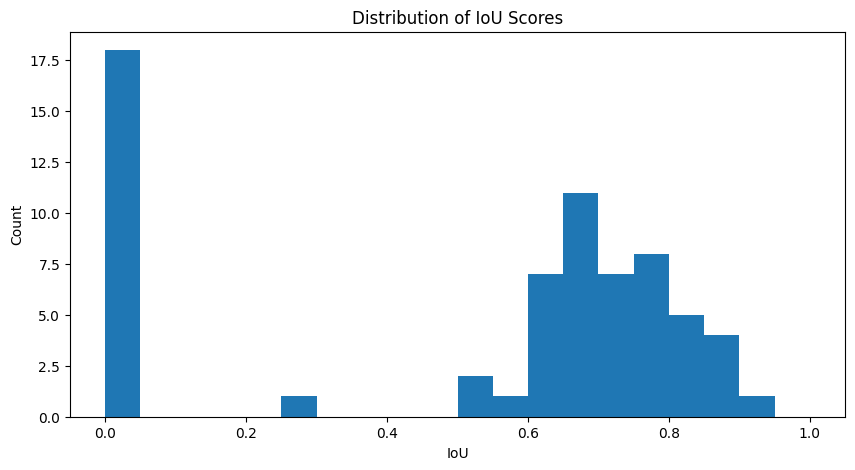

In [85]:
def calculate_statistics(model, test_dir):
    all_ious = []
    all_confidences = []
    true_positives = 0
    false_positives = 0
    false_negatives = 0
    
    image_files = list(Path(test_dir).glob('*.jpg'))
    
    for img_path in image_files:
        # Get image dimensions for normalization
        img = cv2.imread(str(img_path))
        img_height, img_width = img.shape[:2]
        
        # Get corresponding label path
        label_path = img_path.parent.parent.parent / 'labels' / 'test' / (img_path.stem + '.txt')
        
        # Get model predictions and normalize them
        results = model.predict(source=img_path, conf=0.25)
        pred_boxes = results[0].boxes
        
        if len(pred_boxes) > 0:
            # Normalize predicted boxes to 0-1 scale
            pred_boxes_norm = pred_boxes.xyxy.clone()
            pred_boxes_norm[:, [0, 2]] /= img_width   # normalize x coordinates
            pred_boxes_norm[:, [1, 3]] /= img_height  # normalize y coordinates
        
        # Get ground truth boxes (already normalized)
        if label_path.exists():
            with open(label_path, 'r') as f:
                gt_boxes = []
                for line in f.readlines():
                    class_id, x, y, w, h = map(float, line.strip().split())
                    # Convert from center format to xyxy format
                    x1 = x - w/2
                    y1 = y - h/2
                    x2 = x + w/2
                    y2 = y + h/2
                    gt_boxes.append([x1, y1, x2, y2])
                gt_boxes = torch.tensor(gt_boxes)
        
        # Calculate IoU
        if len(pred_boxes) > 0 and len(gt_boxes) > 0:
            ious = box_iou(pred_boxes_norm, gt_boxes)
            ious_np = ious.cpu().numpy()
            
            # Get max IoU for each prediction
            max_ious = ious_np.max(axis=1)
            all_ious.extend(max_ious)
            
            # Get confidences
            all_confidences.extend(pred_boxes.conf.cpu().numpy())
            
            # Count TP, FP, FN
            matched_gt = set()
            for i, iou_row in enumerate(ious_np):
                max_iou = max(iou_row)
                if max_iou >= 0.5:  # IoU threshold of 0.5
                    true_positives += 1
                    matched_gt.add(np.argmax(iou_row))
                else:
                    false_positives += 1
            false_negatives += len(gt_boxes) - len(matched_gt)
        
        elif len(pred_boxes) > 0:
            false_positives += len(pred_boxes)
        elif len(gt_boxes) > 0:
            false_negatives += len(gt_boxes)
    
    # Calculate statistics
    mean_iou = np.mean(all_ious) if all_ious else 0
    std_iou = np.std(all_ious) if all_ious else 0
    mean_conf = np.mean(all_confidences) if all_confidences else 0
    
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print("\nDetection Statistics:")
    print(f"Mean IoU: {mean_iou:.3f} ± {std_iou:.3f}")
    print(f"Mean Confidence: {mean_conf:.3f}")
    print(f"\nCounts:")
    print(f"True Positives: {true_positives}")
    print(f"False Positives: {false_positives}")
    print(f"False Negatives: {false_negatives}")
    print(f"\nMetrics:")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1 Score: {f1:.3f}")
    
    if all_ious:
        plt.figure(figsize=(10, 5))
        plt.hist(all_ious, bins=20, range=(0, 1))
        plt.title('Distribution of IoU Scores')
        plt.xlabel('IoU')
        plt.ylabel('Count')
        plt.show()

# Use the function
model = YOLO('/Users/user/projects/VideoUtilities/runs/detect/train28/weights/best.pt')
test_dir = Path('./triggerfish_detection/datasets/dataset_v2/images/test')
calculate_statistics(model, test_dir)

### 6.3 Understanding the results

1. Localization Accuracy (IoU):

* The Mean IoU of 0.517 indicates moderate localization accuracy
* The high standard deviation (±0.334) suggests inconsistent performance - some detections are very accurate while others are quite poor
* Generally, an IoU > 0.5 is considered acceptable, so you're just meeting this threshold on average

2. Confidence Score Performance:
* Mean confidence of 0.602 shows your model is moderately certain about its predictions 
* This moderate confidence aligns well with the actual performance, which is good - the model isn't overconfident

3. Detection Counts:
* Out of 68 true objects (46 TP + 22 FN), your model found 46 correctly
* It made 19 false detections (false positives)
* It missed 22 objects (false negatives)

4. Key Metrics:
* Precision of 0.708: About 71% of your model's detections are correct
* Recall of 0.676: Your model finds about 68% of all actual objects
* F1 Score of 0.692: This balanced metric suggests moderate overall performance


You can visualize the results by running the following code:

Processing image: triggerfish_detection/datasets/dataset_v2/images/test/image_1194.jpg
Looking for label: triggerfish_detection/datasets/dataset_v2/labels/test/image_1194.txt

image 1/1 /Users/user/projects/VideoUtilities/triggerfish_detection/datasets/dataset_v2/images/test/image_1194.jpg: 384x640 3 triggerfishs, 92.3ms
Speed: 3.1ms preprocess, 92.3ms inference, 2.8ms postprocess per image at shape (1, 3, 384, 640)


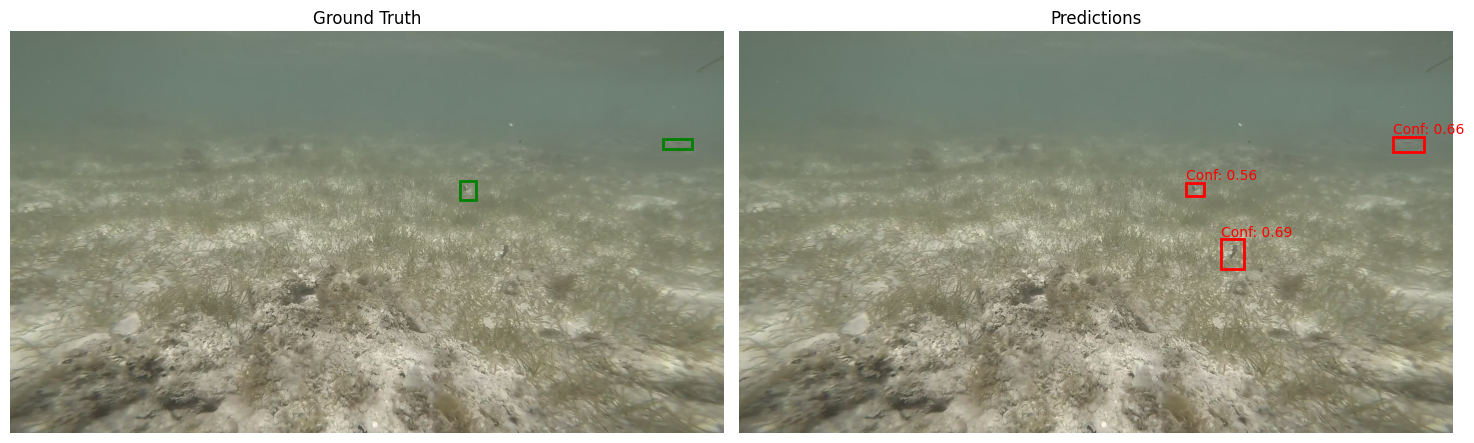

Processing image: triggerfish_detection/datasets/dataset_v2/images/test/image_2746.jpg
Looking for label: triggerfish_detection/datasets/dataset_v2/labels/test/image_2746.txt

image 1/1 /Users/user/projects/VideoUtilities/triggerfish_detection/datasets/dataset_v2/images/test/image_2746.jpg: 384x640 3 triggerfishs, 59.4ms
Speed: 1.3ms preprocess, 59.4ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)


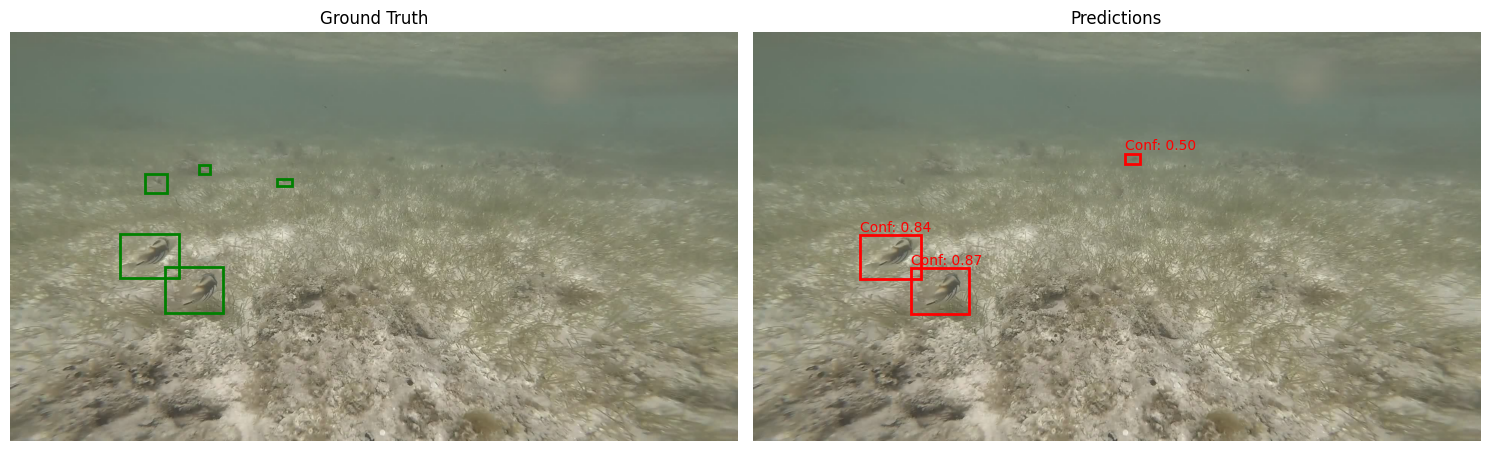

Processing image: triggerfish_detection/datasets/dataset_v2/images/test/image_8032.jpg
Looking for label: triggerfish_detection/datasets/dataset_v2/labels/test/image_8032.txt

image 1/1 /Users/user/projects/VideoUtilities/triggerfish_detection/datasets/dataset_v2/images/test/image_8032.jpg: 384x640 1 triggerfish, 42.6ms
Speed: 1.1ms preprocess, 42.6ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)


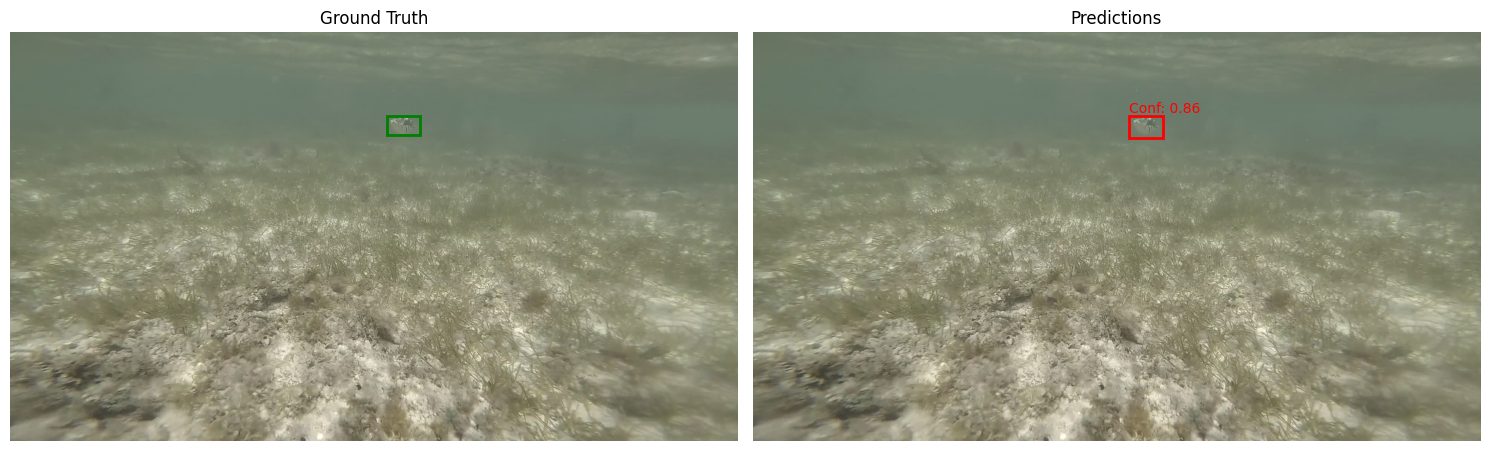

In [86]:
%matplotlib inline
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import random

# Load trained model (if not already loaded)
from ultralytics import YOLO
model = YOLO('/Users/user/projects/VideoUtilities/runs/detect/train28/weights/best.pt')  # update this path

def plot_comparison(image_path, label_path, model):
   # Read image
   img = cv2.imread(str(image_path))
   img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
   
   # Get predictions
   results = model.predict(source=image_path)
   
   # Create two subplots
   fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
   
   # Original image with ground truth
   ax1.imshow(img)
   # Read and plot ground truth boxes
   if label_path.exists():
       with open(label_path, 'r') as f:
           labels = f.readlines()
       for label in labels:
           class_id, x, y, w, h = map(float, label.strip().split())
           # Convert normalized coordinates to pixel coordinates
           H, W = img.shape[:2]
           x1, y1 = int((x - w/2) * W), int((y - h/2) * H)
           x2, y2 = int((x + w/2) * W), int((y + h/2) * H)
           ax1.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='green', linewidth=2))
   ax1.set_title('Ground Truth')
   ax1.axis('off')
   
   # Predictions
   ax2.imshow(img)
   boxes = results[0].boxes
   for box in boxes:
       x1, y1, x2, y2 = box.xyxy[0].numpy()
       ax2.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='red', linewidth=2))
       conf = box.conf.item()
       ax2.text(x1, y1-10, f'Conf: {conf:.2f}', color='red')
   ax2.set_title('Predictions')
   ax2.axis('off')
   
   plt.tight_layout()
   plt.show()

# Update these paths to match your dataset structure
test_dir = Path('./triggerfish_detection/datasets/dataset_v2/images/test')  # Update this path
image_files = list(test_dir.glob('*.jpg'))  # or whatever your image extension is

# Show 3 random examples
for img_path in random.sample(image_files, 3):
   label_path = img_path.parent.parent.parent / 'labels' / 'test' / (img_path.stem + '.txt')
   print(f"Processing image: {img_path}")
   print(f"Looking for label: {label_path}")
   plot_comparison(img_path, label_path, model)

### 6.4 Conclusion and next steps

This model is a good starting point for detecting triggerfish, but there is room for improvement.

Next steps:
* <b>Use more images:</b> This model is trained on 200 images, but we can try again with more images.

* <b>Fine-tune the model:</b> This model only had 20 epochs which is low. We also used a lighter version of YOLOv8 which is not the best model.

* <b>Use a more advanced model architecture:</b> We can try again with a more advanced model architecture.

* <b>Use data augmentation:</b> We can try again with data augmentation. For example, we can use random rotations, translations, and scaling.
